# 🎯 Ejercicios extra de Clasificación

3 mini-problemas en dominios distintos para practicar todo lo de la clase principal.

### 🔁 Cada ejercicio sigue la MISMA estructura (5 pasos)

| Paso | Qué hacer | Tiempo |
|---|---|---|
| **1️⃣ Decidir** | Leed el problema y decidid: ¿priorizáis **PRECISION** o **RECALL**? ¿Por qué? | 2 min |
| **2️⃣ Elegir modelo** | ¿LogisticRegression, KNN, DecisionTree, RandomForest…? Justificad. | 1 min |
| **3️⃣ Entrenar** | `train_test_split` + `.fit()` | 2 min |
| **4️⃣ Métricas** | `classification_report` + matriz de confusión | 2 min |
| **5️⃣ Ajustar threshold** | Si las métricas no convencen, **moved el threshold** y comparad | 3 min |

### 💡 La pregunta clave: ¿qué error duele más?
- Si DUELE más equivocarse al decir SÍ → optimizad **precision**
- Si DUELE más NO detectar un SÍ → optimizad **recall**

### Recordatorio
| Si el coste de… es ALTO | Optimiza | Ejemplos |
|---|---|---|
| Falso positivo (FP) | **Precision** | Spam, marketing caro |
| Falso negativo (FN) | **Recall** | Diagnóstico, seguridad |
| Ambos importan | **F1** | Caso intermedio |



---
## Setup

In [ ]:
# Añadir pip install si necesitais

In [1]:
# Imports comunes a los 3 ejercicios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
print("Setup OK ✅")

Setup OK ✅


---
# 🎓 Ejercicio 1 — Detección de abandono escolar

### 📖 Contexto

Trabajas como data scientist en una **plataforma educativa online** (estilo Coursera o una escuela secundaria virtual). El director te pide un modelo que, a partir de datos de actividad del alumno (horas de conexión, entregas, notas…), prediga **si va a abandonar el curso** (1 = abandona, 0 = sigue).

La idea es identificar a los alumnos en riesgo para que un tutor les escriba y los apoye.

El director te dice: *"Si dejamos pasar a un alumno en riesgo y no le ayudamos, lo perdemos. Eso es un fracaso de nuestro servicio. Si le escribimos a alguien que NO iba a abandonar, no pasa nada — recibe un mensaje amable de su tutor, le sienta bien."*

---

In [ ]:
# ━━━ Datos sintéticos  ━━━
# La función make_classification que usamos para generar los datos de los alumnos no devuelve un DataFrame de Pandas, 
# sino que devuelve un Numpy Array (una matriz de números pura y dura).Los arrays de Numpy son muy eficientes para el cálculo, 
# pero no tienen el método .head(). Ese método es exclusivo de Pandas.
# 1500 alumnos con 8 features simuladas de actividad académica
# 40% de los alumnos acaban abandonando (clase 1)
X1, y1 = make_classification(
    n_samples=1500, n_features=8, n_informative=5,
    weights=[0.6, 0.4],       # 60% siguen, 40% abandonan
    flip_y=0.03,              # 3% de ruido (caso realista)
    random_state=42
)

# y1.mean() es el porcentaje de 1s, es decir, de abandonos. 1 - y1.mean() es el porcentaje de 0s, es decir, de alumnos que 
# siguen.
print(f"Total alumnos: {len(y1)}")
print(f"Siguen (0):    {(y1==0).sum()} ({(1-y1.mean()):.1%})") 
print(f"Abandonan (1): {y1.sum()} ({y1.mean():.1%})")

Total alumnos: 1500
Siguen (0):    891 (59.4%)
Abandonan (1): 609 (40.6%)


In [5]:
# Verificamos estilo Numpy
print("Primeras 3 filas de X1 (Características):")
print(X1[:3]) # Esto significa: desde el principio hasta el índice 3

print("\nPrimeras 3 etiquetas de y1 (Abandono):")
print(y1[:3])

Primeras 3 filas de X1 (Características):
[[-0.33578174 -4.31618079  2.39714706 -3.63497842  3.85250245  3.19010969
   0.34935255  0.99327239]
 [ 0.87873428 -0.3619883  -2.15281899 -0.21278798 -0.46844832  0.90151358
  -0.61824911  1.13287414]
 [ 1.8563937   0.19820595 -2.26995925 -2.44135962 -4.81484098 -1.09121085
   2.33362375  2.80154963]]

Primeras 3 etiquetas de y1 (Abandono):
[0 1 0]


### 1️⃣ Paso 1 — Decisión: ¿priorizas PRECISION o RECALL?

Releed al director:
> *"Si dejamos pasar a un alumno en riesgo, lo perdemos. Eso es un fracaso. Si escribimos a alguien que NO iba a abandonar, no pasa nada — recibe un mensaje amable de su tutor."*

✍️ **Respuesta** (doble-clic):
- Métrica que priorizo: **RECALL**
- Por qué: Porque el objetivo principal es minimizar los Falsos Negativos. Es preferible tener algunos Falsos Positivos (enviar mensajes de apoyo a alumnos que no los necesitaban) que dejar escapar a un alumno en riesgo de abandono sin ofrecerle ayuda, ya que esto último supone la pérdida definitiva del estudiante.

- Regla de oro: Cuando el coste de "omitir" un caso positivo (abandonos, enfermedades, incendios) es mucho más alto que el coste de una "falsa alarma", siempre priorizamos el Recall.

### 2️⃣ Paso 2 — ¿Qué modelo usamos?

Sugerencia: **LogisticRegression**
- Simple y rápido
- Da probabilidades (las necesitaremos para el threshold)
- Interpretable (el director puede ver qué señales activan la alerta)

### 3️⃣ Paso 3 — Entrenar el modelo

Solo tienes que **rellenar las 3 líneas con TODO**.

In [ ]:
# Train / test split (70 / 30, estratificado)
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.3, stratify=y1, random_state=42
)

# crea el modelo LogisticRegression(max_iter=2000)
modelo_1 = LogisticRegression(max_iter=2000) 

# entrénalo con X1_tr, y1_tr
modelo_1.fit(X1_tr, y1_tr)

# predice sobre X1_te (guarda en y1_pred)
y1_pred = modelo_1.predict(X1_te)

print("Modelo entrenado y prediciendo ✅")

Modelo entrenado y prediciendo ✅


In [7]:
# muestro las primeras 10 predicciones y los valores reales para comparar
print("Primeras 10 etiquetas reales de abandono (y1_te):")
print(y1_te[:10])
print("Primeras 10 predicciones de abandono (y1_pred):")
print(y1_pred[:10])

Primeras 10 etiquetas reales de abandono (y1_te):
[1 0 0 0 0 1 0 1 1 0]
Primeras 10 predicciones de abandono (y1_pred):
[1 0 1 0 0 1 0 1 1 0]


### 4️⃣ Paso 4 — Métricas

Imprime el `classification_report` y la matriz de confusión. Mira la fila **"abandona"** y responde:
- ¿Cuánto vale el recall?
- ¿A cuántos alumnos en riesgo NO estamos detectando (FN)?

--- REPORTE DE RENDIMIENTO - EJERCICIO 1 ---
              precision    recall  f1-score   support

       Sigue       0.89      0.93      0.91       267
    Abandona       0.89      0.83      0.86       183

    accuracy                           0.89       450
   macro avg       0.89      0.88      0.88       450
weighted avg       0.89      0.89      0.89       450



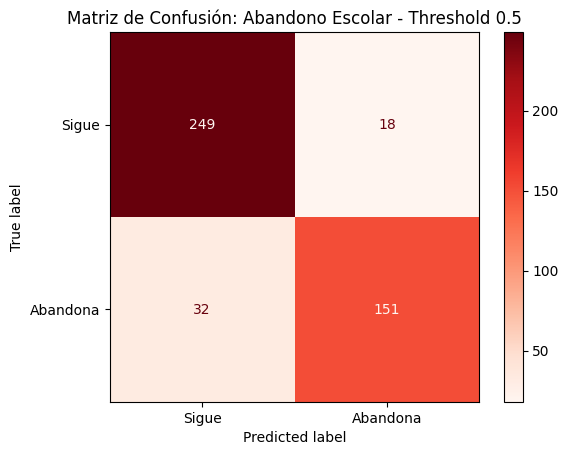

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generamos el reporte completo
print("--- REPORTE DE RENDIMIENTO - EJERCICIO 1 ---")
print(classification_report(y1_te, y1_pred, target_names=['Sigue', 'Abandona']))

# Dibujamos la matriz de confusión
# Aquí veremos cuántos alumnos "en riesgo" se nos han escapado (Falsos Negativos)
ConfusionMatrixDisplay.from_predictions(
    y1_te, y1_pred, 
    display_labels=['Sigue', 'Abandona'], 
    cmap='Reds' # Uso rojo porque el abandono es una alerta
)
plt.title("Matriz de Confusión: Abandono Escolar - Threshold 0.5")
plt.show()

El Recall para la detección de abandonos es 0.83 (83%). Significa que de 100 alumnos que realmente iban a abandonar, tu modelo solo ha sido capaz de "cazar" a 83

 ¿A cuántos alumnos en riesgo NO estamos detectando (FN)? = 32

### 5️⃣ Paso 5 — Ajustar el threshold

Para detectar a MÁS alumnos en riesgo, **bajamos el threshold**.

Prueba con 0.5, 0.4, 0.3 y 0.2.

In [9]:
# Sacamos las probabilidades
y1_proba = modelo_1.predict_proba(X1_te)[:, 1]

print(f"{'thr':>5} | {'precision':>9} | {'recall':>6} | {'FN (no detectados)':>20}")
print("-" * 55)

# TODO: itera sobre los 4 thresholds y calcula precision, recall y FN
for thr in [0.5, 0.4, 0.3, 0.2]:
    pred = (y1_proba >= thr).astype(int)  # aplicar threshold
    p = precision_score(y1_te, pred)     # precision_score
    r = recall_score(y1_te, pred) 
    
    fp= ((pred == 1) & (y1_te == 0)).sum()  # cuenta los FP (predijo 1 "abandona" Y era 0 "sigue")
    fn = ((pred == 0) & (y1_te == 1)).sum()  # cuenta los FN (predijo 0 "sigue" Y era 1 "abandona")
    print(f"{thr:>5} | {p:>9.3f} | {r:>6.3f} | {fn:>20}")

  thr | precision | recall |   FN (no detectados)
-------------------------------------------------------
  0.5 |     0.893 |  0.825 |                   32
  0.4 |     0.830 |  0.907 |                   17
  0.3 |     0.731 |  0.934 |                   12
  0.2 |     0.672 |  0.962 |                    7


---
# 💎 Ejercicio 2 — Campaña de marketing de oferta premium

### 📖 Contexto

Trabajas en una **marca de joyería de lujo**. Quieres lanzar una campaña enviando por correo postal un **catálogo impreso a mano** a clientes que sea probable que **acepten la oferta** (compren) — 1 = comprará, 0 = no comprará.

El responsable de marketing te dice: *"Cada catálogo impreso y enviado nos cuesta 80€. La oferta promedio deja un beneficio de 200€ si compran. Pero si lo mandamos a alguien que no va a comprar, lo tiramos a la basura. Si NO se lo mandamos a alguien que SÍ habría comprado, perdemos esa venta, sí — pero también es cierto que en internet hay miles de clientes potenciales por descubrir. Queremos ser CONSERVADORES con el catálogo."*

---

In [11]:
# ━━━ Datos sintéticos (ya hechos por ti) ━━━
# 2500 clientes, 10 features (perfil demográfico + histórico de compras)
# 30% son compradores potenciales (clase 1)
X2, y2 = make_classification(
    n_samples=2500, n_features=10, n_informative=6,
    weights=[0.7, 0.3],       # 70% no comprarán, 30% sí
    flip_y=0.05,              # 5% de ruido
    random_state=42
)

print(f"Total clientes: {len(y2)}")
print(f"No compran (0): {(y2==0).sum()} ({(1-y2.mean()):.1%})")
print(f"Compran (1):    {y2.sum()} ({y2.mean():.1%})")

Total clientes: 2500
No compran (0): 1723 (68.9%)
Compran (1):    777 (31.1%)


### 1️⃣ Paso 1 — Decisión: ¿priorizas PRECISION o RECALL?

Releed al responsable de marketing:
> *"Cada catálogo cuesta 80€. Si lo mandamos a quien no compra, lo perdemos. Queremos ser CONSERVADORES con el catálogo."*

⚠️ Atención: el caso positivo (1) = "comprará". Si mandamos catálogo a quien NO compra = **FP** (predijimos 1, era 0).

✍️ **Respuesta**:
- Métrica que priorizo: **____**
- Por qué: _______________________________________________

> 💡 Pista: queremos asegurarnos de que cuando decimos *"este va a comprar"*, casi siempre acertamos. Cuando enviamos catálogo, queremos acertar.

### 2️⃣ Paso 2 — ¿Qué modelo usamos?

Sugerencia: **LogisticRegression**
- Sirve bien para problemas tabulares
- Permite mover el threshold cómodamente
- Marketing entiende los coeficientes (qué señales empujan a comprar)

### 3️⃣ Paso 3 — Entrenar el modelo

In [12]:
# Train / test split (70 / 30, estratificado)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.3, stratify=y2, random_state=42
)

# crea el modelo LogisticRegression(max_iter=2000)
modelo_2 = LogisticRegression(max_iter=2000) 

# entrénalo con X2_tr, y2_tr
modelo_2.fit(X2_tr, y2_tr)

# predice sobre X2_te (guarda en y2_pred)
y2_pred = modelo_2.predict(X2_te)

print("Modelo entrenado y prediciendo ✅")

Modelo entrenado y prediciendo ✅


In [14]:
# muestro las primeras 10 predicciones y los valores reales para comparar
print("Primeras 10 etiquetas reales de compra (y2_te):")
print(y2_te[:10])
print("Primeras 10 predicciones de compra (y2_pred):")
print(y2_pred[:10])

Primeras 10 etiquetas reales de compra (y2_te):
[1 0 0 0 0 0 0 0 1 0]
Primeras 10 predicciones de compra (y2_pred):
[1 0 0 0 0 0 0 1 0 0]


### 4️⃣ Paso 4 — Métricas

Mira la fila **"compra"** y responde:
- ¿Cuánta precision tienes? Es decir, de los catálogos enviados, ¿cuántos generan venta?
- ¿Es suficientemente alto?

--- REPORTE DE RENDIMIENTO - EJERCICIO 2 ---
              precision    recall  f1-score   support

   No Compra       0.88      0.93      0.90       517
      Compra       0.82      0.71      0.76       233

    accuracy                           0.86       750
   macro avg       0.85      0.82      0.83       750
weighted avg       0.86      0.86      0.86       750



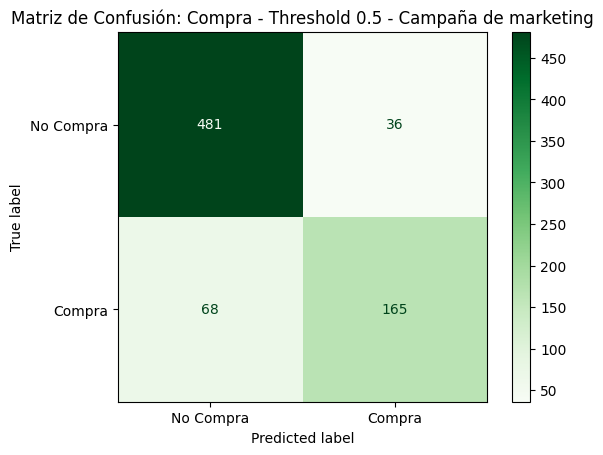

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generamos el reporte completo
print("--- REPORTE DE RENDIMIENTO - EJERCICIO 2 ---")
print(classification_report(y2_te, y2_pred, target_names=['No Compra', 'Compra']))

# Dibujamos la matriz de confusión
# Aquí veremos cuántos alumnos "en riesgo" se nos han escapado (Falsos Negativos)
ConfusionMatrixDisplay.from_predictions(
    y2_te, y2_pred, 
    display_labels=['No Compra', 'Compra'], 
    cmap='Greens' # Uso verde porque el dinero/ beneficio es algo positivo
)
plt.title("Matriz de Confusión: Compra - Threshold 0.5 - Campaña de marketing")
plt.show()

La lógica del negocio vs. La predicción
En este ejercicio, "Enviar un catálogo" es lo mismo que decir que el modelo predijo un 1 (Compra). Por lo tanto, para saber el total de envíos, solo debemos sumar todas las veces que el modelo marcó a alguien con un 1.

- Aciertos (Verdaderos Positivos - TP): El modelo dijo "1" y el cliente compró. Según reporte (Recall 0.71 de 233): 165 personas.
- Errores (Falsos Positivos - FP): El modelo dijo "1" (enviar catálogo) pero el cliente NO compró.Según tu análisis de la gráfica: 36 personas.

- Total de catálogos enviados = Predicciones de Compra (TP + FP) = { 165 (Aciertos)} + 36 (Errores)} = {201 { envíos}}

"Con un threshold de 0.5, el modelo envía 201 catálogos. De esos, 36 son desperdicio directo (80€ x 36 = 2.880€). Si subimos la precisión, este número de 201 bajará, enviando catálogos solo a quienes tengan una probabilidad altísima de compra."

In [16]:
# Sumamos todos los valores donde la predicción fue 1
total_envios = y2_pred.sum()

print(f"El modelo decidió enviar: {total_envios} catálogos")

El modelo decidió enviar: 201 catálogos


### 5️⃣ Paso 5 — Ajustar el threshold

Para subir la **precision** (más confianza al mandar catálogo), **subimos el threshold**.

Prueba con 0.5, 0.6, 0.7 y 0.8.

In [ ]:
y2_proba = modelo_2.predict_proba(X2_te)[:, 1]

print(f"{'thr':>5} | {'precision':>9} | {'recall':>6} | {'FP (catálogos perdidos)':>25}")
print("-" * 60)

# TODO: itera sobre 4 thresholds
for thr in [0.5, 0.6, 0.7, 0.8]:
    pred = ...
    p = ...
    r = ...
    fp = ...    # FP = mandamos catálogo Y no compró
    print(f"{thr:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>25}")

In [17]:
y2_proba = modelo_2.predict_proba(X2_te)[:, 1]

print(f"{'thr':>5} | {'precision':>9} | {'recall':>6} | {'FP (catálogos perdidos)':>25}")
print("-" * 60)

# TODO: itera sobre 4 thresholds
for thr in [0.5, 0.6, 0.7, 0.8]:
    pred = (y2_proba >= thr).astype(int)
    p = precision_score(y2_te, pred)
    r = recall_score(y2_te, pred)
    
    
    fp = ((pred == 1) & (y2_te == 0)).sum()  # FP = mandamos catálogo Y no compró
    fn = ((pred == 0) & (y2_te == 1)).sum()  # FN = no mandamos catálogo Y sí compró
    print(f"{thr:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>25}")

  thr | precision | recall |   FP (catálogos perdidos)
------------------------------------------------------------
  0.5 |     0.821 |  0.708 |                        36
  0.6 |     0.862 |  0.618 |                        23
  0.7 |     0.891 |  0.528 |                        15
  0.8 |     0.923 |  0.412 |                         8


📊 El análisis de la Joyería (Efecto del Threshold)
Cuando subes el umbral (de 0.5 a 0.8), está ocurriendo exactamente lo que el responsable de marketing quería:

Limpieza de "basura": Has pasado de tirar 36 catálogos (2.880€ perdidos) a tirar solo 8 catálogos (640€ perdidos). ¡Has ahorrado a la empresa más de 2.200€ solo moviendo un parámetro!

Seguridad (Precision): Al nivel 0.8, tienes una precisión del 92.3%. Esto significa que cuando el modelo dice "envía", aciertas casi siempre.

El sacrificio (Recall): Fíjate en el Recall. Ha bajado de 0.708 a 0.412. Esto significa que ahora solo detectas al 41% de los compradores. Estás dejando de ganar mucho dinero de "oportunidad", pero te aseguras de que el dinero que gastas en folletos está muy bien invertido.

Basándote en tus propios datos, una respuesta de diez sería:

"Elegiría el threshold de 0.7 o 0.8. Aunque el Recall baja (detectamos menos compradores), la Precision sube por encima del 89-92%. Dado que cada catálogo es muy caro (80€), el objetivo de ser 'conservadores' se cumple mejor aquí, ya que minimizamos los Falsos Positivos (catálogos perdidos) a menos de 10, optimizando el presupuesto de marketing.

---
# 🏭 Ejercicio 3 — Mantenimiento predictivo industrial

### 📖 Contexto

Trabajas como data scientist en una **fábrica de envases**. Tienen sensores en sus máquinas (temperatura, vibración, presión…) y quieren un modelo que prediga si la máquina va a **fallar en las próximas 48h** (1 = fallará, 0 = OK).

Si predicen que va a fallar, paran la máquina y la revisan. El jefe de planta te dice: *"Cada fallo que NO detectamos a tiempo nos para la línea de producción durante 4 horas. Pérdidas: ~15.000€ + clientes enfadados por retrasos. Cada revisión preventiva 'innecesaria' nos cuesta 30 minutos parada + revisión técnica = ~500€."*

⚠️ **OJO**: este dataset está **muy desbalanceado** — solo el 10% de las observaciones acaban en fallo.

---

In [18]:
# ━━━ Datos sintéticos desbalanceados (ya hechos por ti) ━━━
# 4000 observaciones de sensores, 12 features, 10% acaban en fallo
X3, y3 = make_classification(
    n_samples=4000, n_features=12, n_informative=7,
    weights=[0.9, 0.1],       # 90% OK, 10% fallo
    flip_y=0, random_state=42
)

print(f"Total observaciones: {len(y3)}")
print(f"OK (0):     {(y3==0).sum()} ({(1-y3.mean()):.1%})")
print(f"Fallo (1):  {y3.sum()} ({y3.mean():.1%})")

Total observaciones: 4000
OK (0):     3600 (90.0%)
Fallo (1):  400 (10.0%)


### 1️⃣ Paso 1 — Decisión: ¿priorizas PRECISION o RECALL?

Releed al jefe de planta:
> *"Cada fallo NO detectado a tiempo = 15.000€ + clientes enfadados. Cada revisión preventiva innecesaria = 500€."*

Haced el cálculo mental: 15.000€ vs 500€ → **un fallo perdido cuesta 30× más que una revisión innecesaria**.

✍️ **Respuesta**:
- Métrica que priorizo: **____**
- Por qué: _______________________________________________

### 2️⃣ Paso 2 — ¿Qué modelo usamos?

Sugerencia: **RandomForest**

Por qué RF para este caso:
- Los fallos suelen ser **combinaciones raras** de señales de sensores (no relaciones lineales)
- No necesita escalar las features (cada sensor está en una escala distinta)
- Funciona bien con datasets desbalanceados

### 3️⃣ Paso 3 — Entrenar el modelo

In [19]:
X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.3, stratify=y3, random_state=42
)

# TODO: crea RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# TODO: entrena
modelo_3.fit(X3_tr, y3_tr)

# TODO: predice
y3_pred = modelo_3.predict(X3_te)

print("Modelo entrenado ✅")

Modelo entrenado ✅


### 4️⃣ Paso 4 — Métricas

⚠️ NO te dejes engañar por la accuracy (siempre va a ser alta con desbalance). Mira la fila **"fallo"**:
- ¿Qué recall tienes? (cuántos fallos detectas)
- ¿Cuántos se nos escapan (FN)?

--- REPORTE DE RENDIMIENTO - EJERCICIO 3 (MANTENIMIENTO) ---
              precision    recall  f1-score   support

  Sistema OK       0.95      1.00      0.98      1080
       Fallo       0.99      0.57      0.72       120

    accuracy                           0.96      1200
   macro avg       0.97      0.78      0.85      1200
weighted avg       0.96      0.96      0.95      1200



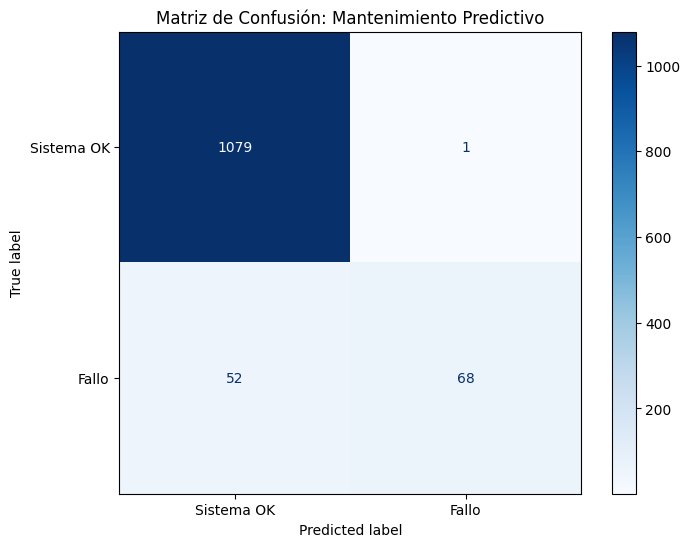

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Reporte de métricas
print("--- REPORTE DE RENDIMIENTO - EJERCICIO 3 (MANTENIMIENTO) ---")
# Usamos y3_te e y3_pred
print(classification_report(y3_te, y3_pred, target_names=['Sistema OK', 'Fallo']))

# 2. Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y3_te, y3_pred, 
    display_labels=['Sistema OK', 'Fallo'], 
    cmap='Blues',
    ax=ax
)
plt.title("Matriz de Confusión: Mantenimiento Predictivo")
plt.show()

### 5️⃣ Paso 5 — Ajustar el threshold

Como queremos pillar el máximo de fallos, **bajamos el threshold**.

Prueba con 0.5, 0.3, 0.2 y 0.1.

In [ ]:
y3_proba = modelo_3.predict_proba(X3_te)[:, 1]

print(f"{'thr':>5} | {'precision':>9} | {'recall':>6} | {'FN (fallos no detectados)':>27}")
print("-" * 60)

# TODO: itera sobre 4 thresholds
for thr in [0.5, 0.3, 0.2, 0.1]:
    pred = ...
    p = ...
    r = ...
    fn = ...
    print(f"{thr:>5} | {p:>9.3f} | {r:>6.3f} | {fn:>27}")

---
## 🎓 ¿Qué te llevas de estos 3 ejercicios?

### 🧠 Las 3 ideas que te llevas a casa

1. **El contexto define la métrica.** No hay métrica "mejor" en abstracto — depende de qué error duele más en TU negocio.
2. **El threshold es tu mando de control.** Bajar = más recall. Subir = más precision. No hay magia.
3. **El código siempre es el mismo.** Cambia el modelo, cambia el dataset, cambia el threshold, pero el patrón `fit → predict → classification_report` no cambia nunca.

### 🌍 Estos 3 problemas existen REALMENTE en producción
- **Abandono escolar**: Coursera, Khan Academy, Duolingo… todas tienen modelos así.
- **Marketing premium**: cualquier marca de lujo (Cartier, Loewe, Rolex…) hace targeting así.
- **Mantenimiento predictivo**: GE, Siemens, ABB, Rolls-Royce (aviones)… mueve miles de millones al año.
